# HPDC Exercise 1 by Alvaro Garmendia and Abdulghani Almasri
## I compiled the code using  mpicxx -O3 flood.cpp -o flood_test, so I do not have a Makefile. I also recommend looking at the HTML pdf, as it rendered better than the straight ipynb to pdf converter.

# Exercise 1
## 1. Projecting the First Zettaflop Supercomputer
Applying Moore’s Law to the current leader of the TOP500 list to estimate when we will reach the "Zettascale" era.

**Current Statistics (November 2024):**
* **Fastest System:** El Capitan (Lawrence Livermore National Laboratory, USA)
* **Current Performance ($R_{max}$):** ~1.742 Exaflops ($1.742 \times 10^{18}$ FLOPS)
* **Target Performance:** 1 Zettaflop ($10^{21}$ FLOPS or 1,000 Exaflops)

**Moore's Law:**
Moore’s Law suggests a doubling of capability approximately every **24 months (2 years)**.

1.  **Growth factor:**
    $$\text{Growth Factor} = \frac{\text{Target}}{\text{Current}} = \frac{1,000 \text{ Exaflops}}{1.742 \text{ Exaflops}} \approx 574.05$$

2.  **Number of doublings ($n$) needed:**
    $$2^n = 574.05$$
    $$n = \log_2(574.05) \approx 9.165 \text{ doublings}$$

3.  **In years:**
    $$\text{Years} = 9.165 \text{ doublings} \times 2 \text{ years/doubling} \approx 18.33 \text{ years}$$

**Conclusion:**
Starting from late 2024, if we follow the standard 2-year Moore's Law cycle, the performance of the fastest supercomputer is projected to exceed one Zettaflop in **mid-2043**.

---

## 2. Exponential Growth Rate (2007–2011)
To determine the specific growth rate during this historical peak, we use the $R_{max}$ values from the November TOP500 lists.

**Data Points:**
* **Nov 2007 ($V_{initial}$):** 478.2 TFlop/s (BlueGene/L)
* **Nov 2011 ($V_{final}$):** 10,510 TFlop/s (K computer)
* **Time Interval ($\Delta t$):** 4 years

**Determining the Annual Growth Rate ($r$):**
Using the exponential growth formula $V_{final} = V_{initial} \times (1 + r)^{\Delta t}$:

1.  **Set up the equation:**
    $$10,510 = 478.2 \times (1 + r)^4$$

2.  **Solve for $r$:**
    $$\frac{10,510}{478.2} = (1 + r)^4$$
    $$21.978 \approx (1 + r)^4$$
    $$\sqrt[4]{21.978} = 1 + r$$
    $$2.164 \approx 1 + r$$
    $$r \approx 1.164$$

**Results:**
* **Annual Growth Rate:** **116.4% per year**.
* **Doubling Time:** During this specific period, performance was doubling every **~0.9 years (approx. 11 months)**.



---

### Comparison Summary
| Metric | Moore's Law (Theoretical) | TOP500 Observed (2007-2011) |
| :--- | :--- | :--- |
| **Growth Rate (p.a.)** | ~41% | ~116% |
| **Doubling Time** | 24 Months | ~11 Months |
| **Zettaflop Era** | ~2043 | ~2034 (if rate was sustained) |

# Exercise 2

## 1. Webserver CPU Performance Improvement
Using Amdahl's Law to calculate the overall speedup of a system when only a portion of the task is accelerated.

**Given:**
* **Improvable fraction ($p$):** 0.40 (40% calculation time)
* **Non-improvable fraction ($1-p$):** 0.60 (60% IO time)
* **Speedup of the improved part ($s$):** 10

**Calculation:**
$$S_{overall} = \frac{1}{(1 - p) + \frac{p}{s}}$$
$$S_{overall} = \frac{1}{0.6 + \frac{0.4}{10}} = \frac{1}{0.6 + 0.04} = \frac{1}{0.64}$$
$$S_{overall} = 1.5625$$

**Result:**
The expected overall performance improvement is **1.56x**.

---

## 2. Optimization Strategy Comparison
We evaluate two alternatives to identify which provides the highest total system speedup.

### Alternative 1: Optimize FPSQR
* **Fraction ($p_1$):** 0.20
* **Speedup ($s_1$):** 10
$$S_{Alt1} = \frac{1}{(1 - 0.2) + \frac{0.2}{10}} = \frac{1}{0.8 + 0.02} \approx \mathbf{1.220x}$$

### Alternative 2: Optimize all FP operations
* **Fraction ($p_2$):** 0.50 (Given that half the time is spent on FP)
* **Speedup ($s_2$):** 1.6
$$S_{Alt2} = \frac{1}{(1 - 0.5) + \frac{0.5}{1.6}} = \frac{1}{0.5 + 0.3125} \approx \mathbf{1.231x}$$

**Conclusion:**
**Alternative 2** is the optimal solution. Although the speedup factor is lower (1.6 vs 10), it targets a much larger portion of the execution time, resulting in a better overall gain.

---

## 3. Parallel Program Serial Fraction
To find the maximum allowable serial fraction ($f$) for a target speedup on a specific number of processors.

**Given:**
* **Target Speedup ($S$):** 100
* **Number of Processors ($n$):** 128

**Formula:**
$$S = \frac{1}{f + \frac{1 - f}{n}}$$

**Step-by-Step Solution:**
1.  **Plug in the values:**
    $$100 = \frac{1}{f + \frac{1 - f}{128}}$$
2.  **Invert and solve for the denominator:**
    $$0.01 = f + \frac{1 - f}{128}$$
3.  **Multiply by 128 to eliminate the fraction:**
    $$1.28 = 128f + 1 - f$$
4.  **Isolate $f$:**
    $$1.28 - 1 = 127f$$
    $$0.28 = 127f$$
    $$f = \frac{0.28}{127} \approx 0.0022047$$

**Result:**
The serial fraction of the application can be at most **~0.22%** to achieve a 100x speedup on 128 processors.

# Exercise 3

This benchmark measures the point-to-point communication performance of the cluster using a "ping-pong" method. The following tables summarize the **Round-Trip Time (RTT)** and **Half-RTT** (one-way latency) for all measured message sizes. (relevant code further down)

### 1. Full Results Tables

#### Intra-node Performance (1 Node)
*Two processes running on the same physical AMD EPYC CPU.*

| # Bytes | Full-RTT (s) | Half-RTT (s) |
| :--- | :--- | :--- |
| 1 | 7.334180e-07 | 3.667090e-07 |
| 2 | 6.285520e-07 | 3.142760e-07 |
| 4 | 6.286580e-07 | 3.143290e-07 |
| 8 | 6.260020e-07 | 3.130010e-07 |
| 16 | 6.244400e-07 | 3.122200e-07 |
| 32 | 6.264720e-07 | 3.132360e-07 |
| 64 | 6.364380e-07 | 3.182190e-07 |
| 128 | 6.480640e-07 | 3.240320e-07 |
| 256 | 6.953400e-07 | 3.476700e-07 |
| 512 | 9.181780e-07 | 4.590890e-07 |
| 1024 | 1.318428e-06 | 6.592140e-07 |
| 2048 | 1.334830e-06 | 6.674150e-07 |
| 4096 | 6.811460e-06 | 3.405730e-06 |
| 8192 | 7.852676e-06 | 3.926338e-06 |
| 16384 | 9.998246e-06 | 4.999123e-06 |
| 32768 | 1.401382e-05 | 7.006909e-06 |
| 65536 | 2.390517e-05 | 1.195258e-05 |
| 131072 | 4.266785e-05 | 2.133392e-05 |
| 262144 | 8.192031e-05 | 4.096016e-05 |
| 524288 | 1.580177e-04 | 7.900886e-05 |
| 1048576 | 3.044542e-04 | 1.522271e-04 |

---

#### Inter-node Performance (2 Nodes)
*Two processes communicating over Gigabit Ethernet.*

| # Bytes | Full-RTT (s) | Half-RTT (s) |
| :--- | :--- | :--- |
| 1 | 8.795706e-05 | 4.397853e-05 |
| 2 | 8.425630e-05 | 4.212815e-05 |
| 4 | 8.442077e-05 | 4.221039e-05 |
| 8 | 8.466897e-05 | 4.233448e-05 |
| 16 | 8.624313e-05 | 4.312156e-05 |
| 32 | 8.528412e-05 | 4.264206e-05 |
| 64 | 8.672995e-05 | 4.336498e-05 |
| 128 | 9.084459e-05 | 4.542230e-05 |
| 256 | 9.352088e-05 | 4.676044e-05 |
| 512 | 1.021387e-04 | 5.106934e-05 |
| 1024 | 1.220690e-04 | 6.103449e-05 |
| 2048 | 1.652983e-04 | 8.264916e-05 |
| 4096 | 3.156844e-04 | 1.578422e-04 |
| 8192 | 4.169948e-04 | 2.084974e-04 |
| 16384 | 5.093559e-04 | 2.546779e-04 |
| 32768 | 8.684064e-04 | 4.342032e-04 |
| 65536 | 1.888274e-03 | 9.441372e-04 |
| 131072 | 3.039441e-03 | 1.519720e-03 |

---

### 2. Discussion of Results

#### Startup Latency ($ \alpha $)
The "zero-byte" latency (1 Byte) shows the overhead of the physical network:
- **Intra-node:** ~0.37 µs. This reflects the speed of shared-memory operations within the CPU's local domain.
- **Inter-node:** ~44 µs. This is around **120 times slower** than intra-node communication. This overhead is caused by the Gigabit Ethernet stack and other infrastructure overheads.

#### Bandwidth Comparison ($ \beta $)
As message sizes increase, the difference in transmission mediums becomes the bottleneck:
- **Intra-node:** Even at 1 MB, latency remains low (0.15 ms).
- **Inter-node:** Latency scales linearly. At 128 KB, inter-node latency is **71 times higher** than intra-node (1.5 ms vs 21 µs). Given the 1 Gbps (125 MB/s) hardware limit of the cluster's Ethernet, larger data transfers are very constrained by the network.

#### The MPI Protocol Switch
A clear "jump" in latency is observed in the 1-node results between **2,048 Bytes (0.6 µs)** and **4,096 Bytes (3.4 µs)**. This points to a change in the MPI communication protocol:
1. **Eager Protocol:** Used for small messages (up to 2 KB here); data is sent immediately, assuming the receiver has buffer space.
2. **Rendezvous Protocol:** Triggered at 4 KB; a handshake is performed to synchronize sender and receiver, ensuring data safety for larger payloads at the cost of higher base latency.

### 3. Conclusion
The data highlights that for HPDC applications, task placement is critical. Mapping communication-heavy processes to the same node can reduce latency from the millisecond range down to sub-microsecond levels, bypassing the bottlenecks of the Gigabit Ethernet interconnect.

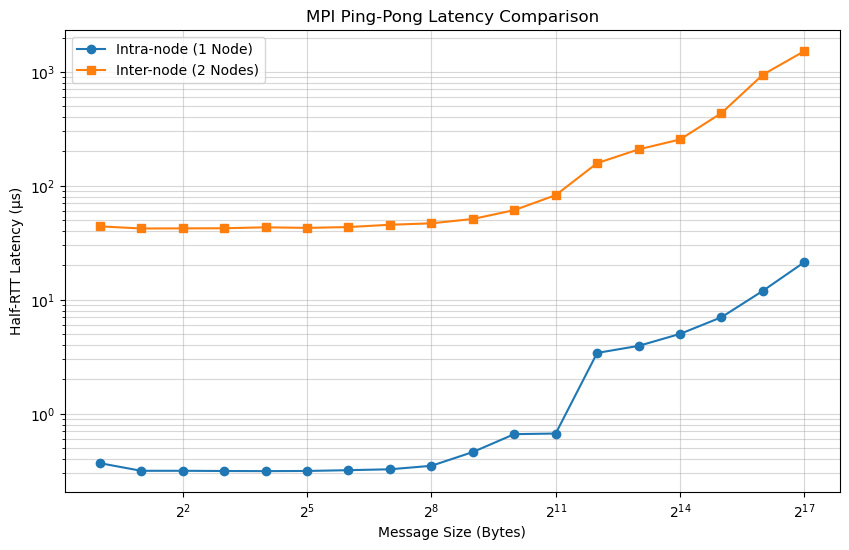

In [2]:
import matplotlib.pyplot as plt

# Data from your results
bytes_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

# Half-RTT in seconds (truncated to match 2-node data length)
latency_1n = [3.667e-07, 3.142e-07, 3.143e-07, 3.130e-07, 3.122e-07, 3.132e-07, 3.182e-07, 3.240e-07, 3.476e-07, 4.590e-07, 6.592e-07, 6.674e-07, 3.405e-06, 3.926e-06, 4.999e-06, 7.006e-06, 1.195e-05, 2.133e-05]
latency_2n = [4.397e-05, 4.212e-05, 4.221e-05, 4.233e-05, 4.312e-05, 4.264e-05, 4.336e-05, 4.542e-05, 4.676e-05, 5.106e-05, 6.103e-05, 8.264e-05, 1.578e-04, 2.084e-04, 2.546e-04, 4.342e-04, 9.441e-04, 1.519e-03]

# Convert to microseconds
l1_us = [x * 1e6 for x in latency_1n]
l2_us = [x * 1e6 for x in latency_2n]

plt.figure(figsize=(10, 6))
plt.plot(bytes_sizes, l1_us, marker='o', label='Intra-node (1 Node)')
plt.plot(bytes_sizes, l2_us, marker='s', label='Inter-node (2 Nodes)')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Message Size (Bytes)')
plt.ylabel('Half-RTT Latency (µs)')
plt.title('MPI Ping-Pong Latency Comparison')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.savefig('latency_plot.png')

```cpp
#include <iostream>
#include <vector>
#include <iomanip>
#include <mpi.h>

int main(int argc, char **argv)
{
    MPI_Init(&argc, &argv);

    int world_rank, world_size;
    MPI_Comm_rank(MPI_COMM_WORLD, &world_rank);
    MPI_Comm_size(MPI_COMM_WORLD, &world_size);

    // Basic error checking
    if (world_size != 2)
    {
        if (world_rank == 0)
        {
            std::cerr << "Error: This program must be run with exactly 2 processes. It was run by: " << world_size << std::endl;
        }
        MPI_Finalize();
        return 1;
    }

    const int MAX_EXP = 20;     // Up to 1MB (2^20)
    const int ITERATIONS = 500; // Increased iterations for more stable results

    if (world_rank == 0)
    {
        std::cout << std::left << std::setw(15) << "# Bytes"
                  << std::setw(20) << "Full-RTT (s)"
                  << std::setw(20) << "Half-RTT (s)" << std::endl;
        std::cout << std::string(55, '-') << std::endl;
    }

    for (int i = 0; i <= MAX_EXP; i++)
    {
        size_t message_size = 1 << i;
        std::vector<char> buffer(message_size, 'a');

        // Synchronize before measurement
        MPI_Barrier(MPI_COMM_WORLD);

        double start_time = MPI_Wtime();

        for (int j = 0; j < ITERATIONS; j++)
        {
            if (world_rank == 0)
            {
                MPI_Send(buffer.data(), message_size, MPI_CHAR, 1, 0, MPI_COMM_WORLD);
                MPI_Recv(buffer.data(), message_size, MPI_CHAR, 1, 0, MPI_COMM_WORLD, MPI_STATUS_IGNORE);
            }
            else
            {
                MPI_Recv(buffer.data(), message_size, MPI_CHAR, 0, 0, MPI_COMM_WORLD, MPI_STATUS_IGNORE);
                MPI_Send(buffer.data(), message_size, MPI_CHAR, 0, 0, MPI_COMM_WORLD);
            }
        }

        double end_time = MPI_Wtime();

        if (world_rank == 0)
        {
            double total_time = end_time - start_time;
            double avg_rtt = total_time / ITERATIONS;
            double latency = avg_rtt / 2.0;

            std::cout << std::left << std::setw(15) << message_size
                      << std::setw(20) << std::scientific << avg_rtt
                      << std::setw(20) << std::scientific << latency << std::endl;
        }
    }

    MPI_Finalize();
    return 0;
}


## 1.4 Bandwidth Measurement (Flood Test)

The code is below. We compare blocking (`MPI_Send`) vs. non-blocking (`MPI_Isend`) operations.

### 1. Results Data
**Execution Environment:** 2 Nodes (Inter-node), Gigabit Ethernet, `--exclusive` allocation.

| # Bytes | Blocking (MB/s) | Non-Blocking (MB/s) |
| :--- | :--- | :--- |
| 1 | 0.17 | 0.13 |
| 2 | 0.40 | 0.32 |
| 4 | 0.65 | 0.66 |
| 8 | 1.95 | 1.81 |
| 16 | 4.04 | 4.42 |
| 32 | 9.26 | 10.74 |
| 64 | 23.64 | 22.71 |
| 128 | 49.44 | 50.69 |
| 256 | 118.83 | 108.61 |
| 512 | 259.46 | 267.23 |
| 1,024 | 514.50 | 563.99 |
| 2,048 | 351.75 | 503.65 |
| 4,096 | 275.56 | 239.11 |
| 8,192 | 152.39 | 171.75 |
| 16,384 | 134.88 | 133.16 |
| 32,768 | 123.23 | 123.18 |
| 65,536 | 81.18 | 116.61 |
| 131,072 | 93.33 | 115.09 |
| 262,144 | 100.65 | 114.60 |

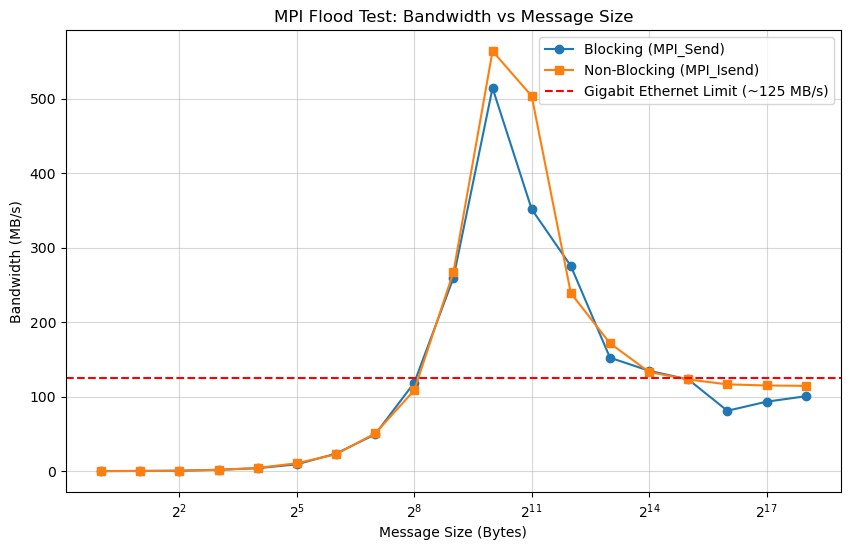

In [3]:
import matplotlib.pyplot as plt

# Data
bytes_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]
blocking_bw = [0.17, 0.40, 0.65, 1.95, 4.04, 9.26, 23.64, 49.44, 118.83, 259.46, 514.50, 351.75, 275.56, 152.39, 134.88, 123.23, 81.18, 93.33, 100.65]
non_blocking_bw = [0.13, 0.32, 0.66, 1.81, 4.42, 10.74, 22.71, 50.69, 108.61, 267.23, 563.99, 503.65, 239.11, 171.75, 133.16, 123.18, 116.61, 115.09, 114.60]

plt.figure(figsize=(10, 6))
plt.plot(bytes_sizes, blocking_bw, marker='o', label='Blocking (MPI_Send)')
plt.plot(bytes_sizes, non_blocking_bw, marker='s', label='Non-Blocking (MPI_Isend)')

plt.xscale('log', base=2)
plt.xlabel('Message Size (Bytes)')
plt.ylabel('Bandwidth (MB/s)')
plt.title('MPI Flood Test: Bandwidth vs Message Size')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.axhline(y=125, color='r', linestyle='--', label='Gigabit Ethernet Limit (~125 MB/s)')
plt.legend()

plt.savefig('bandwidth_plot.png')
plt.show()

### Discussion of Results

#### 1. The Gigabit Ethernet Bottleneck
For larger message sizes (starting around 8,192 bytes and up), the bandwidth converges toward a specific ceiling. Since the cluster uses Gigabit Ethernet, the theoretical maximum bandwidth is $125 \text{ MB/s}$ ($1 \text{ Gbps} / 8$). The results plateau around there, showing that the network is saturated and it becomes the primary bottleneck.

#### 2. The middle Spike
At thespike at 1,024 bytes, the bandwidth hits 563 MB/s. This value is physically impossible for a Gigabit Ethernet cable. This is a result of the Eager Protocol. MPI copies these small messages into a local buffer on the receiver side immediately. The benchmark is essentially measuring the speed of local memory copies rather than the actual time the data takes to travel across the network.
At 4,096 bytes, the bandwidth drops sharply. This is the Rendezvous Protocol threshold. MPI stops "blindly" sending data and starts a handshake to ensure the receiver has space. This forces the sender to wait for the actual network speed, hence we see the true performance of the Ethernet link.

#### 3. Blocking vs. Non-Blocking Performance
* **Overhead at Small Sizes:** For the smallest messages (1–2 bytes), Blocking is actually slightly faster. This is because the overhead of creating, tracking, and cleaning up `MPI_Request` handles for Non-Blocking calls exceeds the actual data transfer time.
* **Saturation Efficiency:** As message sizes increase, Non-Blocking (`MPI_Isend`) consistently outperforms Blocking (`MPI_Send`). For example, at 65,536 bytes, Blocking drops to 81.18 MB/s while Non-Blocking maintains 116.61 MB/s. 
* **Reasoning:** `MPI_Isend` allows the MPI library to queue multiple packets into the Network Interface Card's (NIC) buffer. This ensures the "pipe" stays full. In contrast, `MPI_Send` often results in small gaps of "idle wire" time while the CPU processes the loop and waits for the specific acknowledgment of the previous send.

#### 4. Conclusion
Message size is the most critical factor for bandwidth efficiency. Small messages are latency-bound (limited by the number of messages per second), while large messages are bandwidth-bound (limited by the physical hardware). Non-blocking operations are the preferred choice for high-performance applications as they better saturate the available interconnect by overlapping communication requests.

```cpp
#include <iostream>
#include <vector>
#include <iomanip>
#include <mpi.h>

int main(int argc, char **argv)
{
    // Use a specific threading level if required by the cluster,
    // though Init is usually fine for this test.
    MPI_Init(&argc, &argv);

    int world_rank, world_size;
    MPI_Comm_rank(MPI_COMM_WORLD, &world_rank);
    MPI_Comm_size(MPI_COMM_WORLD, &world_size);

    if (world_size != 2)
    {
        if (world_rank == 0)
            std::cerr << "Error: Use 2 processes." << std::endl;
        MPI_Finalize();
        return 1;
    }

    const int MAX_EXP = 20;
    const int ITERATIONS = 1000;

    if (world_rank == 0)
    {
        std::cout << std::left << std::setw(12) << "# Bytes"
                  << std::setw(20) << "Blocking (MB/s)"
                  << std::setw(20) << "Non-Blocking (MB/s)" << std::endl;
        std::cout << std::string(52, '-') << std::endl;
    }

    for (int i = 0; i <= MAX_EXP; i++)
    {
        int message_size = 1 << i; // Use int to match MPI count parameters
        std::vector<char> buffer(message_size, 'f');
        double start_time, end_time;

        // --- 1. BLOCKING SEND TEST ---
        MPI_Barrier(MPI_COMM_WORLD);
        start_time = MPI_Wtime();

        for (int j = 0; j < ITERATIONS; j++)
        {
            if (world_rank == 0)
            {
                MPI_Send(buffer.data(), message_size, MPI_CHAR, 1, 0, MPI_COMM_WORLD);
            }
            else
            {
                MPI_Recv(buffer.data(), message_size, MPI_CHAR, 0, 0, MPI_COMM_WORLD, MPI_STATUS_IGNORE);
            }
        }
        end_time = MPI_Wtime();
        double bw_blocking = (static_cast<double>(message_size) * ITERATIONS) / ((end_time - start_time) * 1024 * 1024);

        // --- 2. NON-BLOCKING SEND TEST ---
        // Using a raw array for requests to be as compatible as possible
        MPI_Request *requests = new MPI_Request[ITERATIONS];

        MPI_Barrier(MPI_COMM_WORLD);
        start_time = MPI_Wtime();

        if (world_rank == 0)
        {
            for (int j = 0; j < ITERATIONS; j++)
            {
                MPI_Isend(buffer.data(), message_size, MPI_CHAR, 1, 0, MPI_COMM_WORLD, &requests[j]);
            }
            MPI_Waitall(ITERATIONS, requests, MPI_STATUSES_IGNORE);
        }
        else
        {
            for (int j = 0; j < ITERATIONS; j++)
            {
                MPI_Irecv(buffer.data(), message_size, MPI_CHAR, 0, 0, MPI_COMM_WORLD, &requests[j]);
            }
            MPI_Waitall(ITERATIONS, requests, MPI_STATUSES_IGNORE);
        }
        end_time = MPI_Wtime();

        double bw_nonblocking = (static_cast<double>(message_size) * ITERATIONS) / ((end_time - start_time) * 1024 * 1024);

        if (world_rank == 0)
        {
            std::cout << std::left << std::setw(12) << message_size
                      << std::setw(20) << std::fixed << std::setprecision(2) << bw_blocking
                      << std::setw(20) << std::fixed << std::setprecision(2) << bw_nonblocking << std::endl;
        }

        delete[] requests;
    }

    MPI_Finalize();
    return 0;
}